In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('base_merged_data', parse_dates=["date"])

In [2]:
#Create Time Feature
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)

In [3]:
#Payday Features
df['is_payday_15'] = (df['day'] == 15).astype(int)
df['is_payday_end_month'] = df['is_month_end']
df['days_Since_payday'] = df['day'] - 15

In [4]:
#Promotion Feature
df['promo_flag'] = (df['onpromotion'] > 0).astype(int)

In [5]:
#Lag Feature
df = df.sort_values(['store_nbr','family','date'])
df['lag_1'] = df.groupby(['store_nbr','family'])['sales'].shift(1)
df['lag_7'] = df.groupby(['store_nbr','family'])['sales'].shift(7)
df['lag_14'] = df.groupby(['store_nbr','family'])['sales'].shift(14)
df['lag_28'] = df.groupby(['store_nbr','family'])['sales'].shift(28)

In [6]:
#Rolling Feature
df['rolling_mean_7'] = (
    df.groupby(['store_nbr','family'])['sales']
    .shift(1)
    .rolling(7)
    .mean()
)
df['rolling_std_7'] = (
    df.groupby(['store_nbr','family'])['sales']
    .shift(1)
    .rolling(7)
    .std()
)
df['rolling_mean_30'] = (
    df.groupby(['store_nbr','family'])['sales']
    .shift(1)
    .rolling(30)
    .mean()
)

In [7]:
#Promotion Flag
df['promo_flag'] = (df['onpromotion'] > 0).astype(int)
df['promo_intensity'] = df['onpromotion']
df['promo_rolling_7'] = (
    df.groupby(['store_nbr','family'])['onpromotion']
    .shift(1)
    .rolling(7)
    .mean()
)

In [8]:
# Holiday flags already engineered in Notebook 01 (holiday_by_date merge)
holiday_flag_cols = [
    'is_holiday','is_transferred',
    'has_national','has_local','has_regional',
    'has_bridge','has_additional','has_event'
]

# If any are missing for some reason, create as 0 (keeps notebook robust)
for c in holiday_flag_cols:
    if c not in df.columns:
        df[c] = 0

# Ensure numeric 0/1
df[holiday_flag_cols] = df[holiday_flag_cols].fillna(0).astype(int)

In [9]:
#Remove NA rows created by lag feature
df = df.dropna()

In [10]:
#Structura;l Validation
print("Shape:", df.shape)
print("\nNull values:\n", df.isnull().sum().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (446580, 40)

Null values:
 0

Duplicate rows: 0


In [11]:
#Lag Leakage Check
sample = df[(df['store_nbr']==1) & (df['family']=='GROCERYI')].head(15)
sample[['date','sales','lag_1','lag_7']]

,date,sales,lag_1,lag_7


In [12]:
#Feature Count Check
df.columns
len(df.columns)

40

In [13]:
df['log_sales'] = np.log1p(df['sales'])

Text(0.5, 1.0, 'Log Sales')

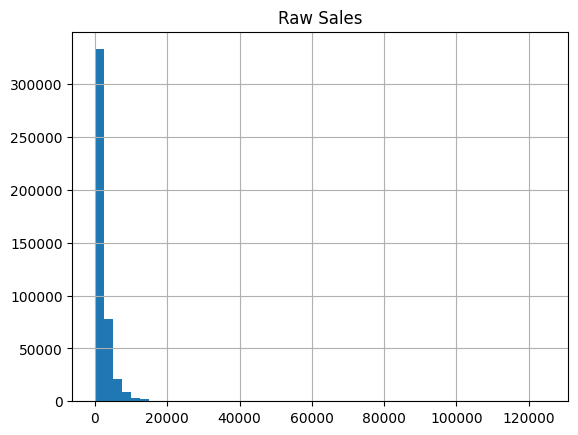

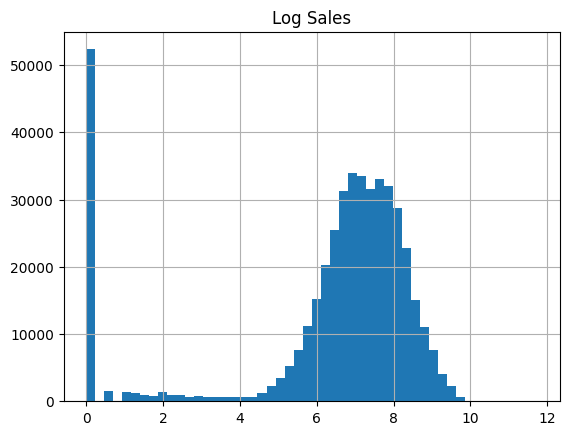

In [14]:
#Distibution Check
import matplotlib.pyplot as plt
df['sales'].hist(bins=50)
plt.title("Raw Sales")
plt.figure()
df['log_sales'].hist(bins=50)
plt.title("Log Sales")

In [15]:
#Time Split Validation
print(df['date'].min(), df['date'].max())

2013-01-31 00:00:00 2017-08-15 00:00:00


In [16]:
df.to_csv("modelling_dataset_top5.csv", index=False)